In [1]:
# Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Success")

Success


In [2]:
price_df = pd.read_csv("/Users/Casual/Documents/TISE/04_UWK/01_Thesis/04_Data/european_wholesale_electricity_price_data_hourly/Ireland.csv")

In [3]:
price_df.head(10)

,Country,ISO3 Code,Datetime (UTC),Datetime (Local),Price (EUR/MWhe)
0,Ireland,IRL,2018-10-01 22:00:00,2018-10-01 23:00:00,71.27
1,Ireland,IRL,2018-10-01 23:00:00,2018-10-02 00:00:00,67.21
2,Ireland,IRL,2018-10-02 00:00:00,2018-10-02 01:00:00,60.50
3,Ireland,IRL,2018-10-02 01:00:00,2018-10-02 02:00:00,63.68
4,Ireland,IRL,2018-10-02 02:00:00,2018-10-02 03:00:00,71.62
5,Ireland,IRL,2018-10-02 03:00:00,2018-10-02 04:00:00,72.86
6,Ireland,IRL,2018-10-02 04:00:00,2018-10-02 05:00:00,76.94
7,Ireland,IRL,2018-10-02 05:00:00,2018-10-02 06:00:00,80.48
8,Ireland,IRL,2018-10-02 06:00:00,2018-10-02 07:00:00,89.71
9,Ireland,IRL,2018-10-02 07:00:00,2018-10-02 08:00:00,127.40


In [4]:
price_df.dtypes
# columns for date is still in string (object). Need to convert it into datetime format

Country              object
ISO3 Code            object
Datetime (UTC)       object
Datetime (Local)     object
Price (EUR/MWhe)    float64
dtype: object

In [5]:
# Convert columns to correct format
price_df["Datetime (Local)"] = pd.to_datetime(price_df["Datetime (Local)"])
price_df["Year"] = price_df["Datetime (Local)"].dt.year
price_df["Date"] = price_df["Datetime (Local)"].dt.date
price_df["Hour"] = price_df["Datetime (Local)"].dt.hour
price_df.head()

# Filter 2023 - 2025
price_df.tail(10)
price_df_filtered = price_df[price_df["Year"].isin([2023, 2024, 2025])]

price_df_filtered.head()
price_df_filtered.tail()

,Country,ISO3 Code,Datetime (UTC),Datetime (Local),Price (EUR/MWhe),Year,Date,Hour
63549,Ireland,IRL,2025-12-31 19:00:00,2025-12-31 19:00:00,174.20,2025,2025-12-31,19
63550,Ireland,IRL,2025-12-31 20:00:00,2025-12-31 20:00:00,160.61,2025,2025-12-31,20
63551,Ireland,IRL,2025-12-31 21:00:00,2025-12-31 21:00:00,127.96,2025,2025-12-31,21
63552,Ireland,IRL,2025-12-31 22:00:00,2025-12-31 22:00:00,122.26,2025,2025-12-31,22
63553,Ireland,IRL,2025-12-31 23:00:00,2025-12-31 23:00:00,122.26,2025,2025-12-31,23


# ----------- AVERAGE SELLING PRICE SECTION ------------
## Max Selling Price
### Average of 4 most expensive hours each day 

In [6]:
# For every day, take the cheapest 4 hours 

expensive_4_hours_sell = (price_df_filtered
    .sort_values(by = ["Date", "Price (EUR/MWhe)"], ascending = [True, False])
    .groupby("Date")
    .head(4)
                         )

expensive_4_hours_sell.head(10)

,Country,ISO3 Code,Datetime (UTC),Datetime (Local),Price (EUR/MWhe),Year,Date,Hour
37267,Ireland,IRL,2023-01-01 17:00:00,2023-01-01 17:00:00,252.00,2023,2023-01-01,17
37266,Ireland,IRL,2023-01-01 16:00:00,2023-01-01 16:00:00,240.00,2023,2023-01-01,16
37268,Ireland,IRL,2023-01-01 18:00:00,2023-01-01 18:00:00,228.00,2023,2023-01-01,18
37262,Ireland,IRL,2023-01-01 12:00:00,2023-01-01 12:00:00,225.00,2023,2023-01-01,12
37291,Ireland,IRL,2023-01-02 17:00:00,2023-01-02 17:00:00,255.00,2023,2023-01-02,17
37292,Ireland,IRL,2023-01-02 18:00:00,2023-01-02 18:00:00,240.20,2023,2023-01-02,18
37290,Ireland,IRL,2023-01-02 16:00:00,2023-01-02 16:00:00,221.00,2023,2023-01-02,16
37293,Ireland,IRL,2023-01-02 19:00:00,2023-01-02 19:00:00,210.37,2023,2023-01-02,19
37315,Ireland,IRL,2023-01-03 17:00:00,2023-01-03 17:00:00,210.49,2023,2023-01-03,17
37310,Ireland,IRL,2023-01-03 12:00:00,2023-01-03 12:00:00,208.56,2023,2023-01-03,12


In [7]:
# Average expensive across 2023 - 2025 (Max Selling Price)
max_selling_price = expensive_4_hours_sell["Price (EUR/MWhe)"].mean()
print("--- Average Prices 2023 - 2025 ---")
print(f"Overall (2023 - 2025): {max_selling_price:.2f}")

yearly_avg_expensive_sell = expensive_4_hours_sell.groupby("Year")["Price (EUR/MWhe)"].mean()
print("--- Average Prices per Year ---")
print(yearly_avg_expensive_sell)

--- Average Prices 2023 - 2025 ---
Overall (2023 - 2025): 162.98
--- Average Prices per Year ---
Year
2023    165.002966
2024    156.123934
2025    167.825870
Name: Price (EUR/MWhe), dtype: float64


## Min Selling Price 
### Approach 1: High-wind Peak Day Prices

Distribution of daily peak prices - some days are much lower, especially high-wind days when renewables suppress prices even during peak hours. When 500 MW of BESS all discharge simultaneously into peak, that's effectively like a high-wind peak day. The lower tail of your daily distribution is your empirically grounded MIN SELLING PRICE.

In [8]:
daily_top4_avg = expensive_4_hours_sell.groupby("Date")["Price (EUR/MWhe)"].mean()
print(daily_top4_avg.describe())
print(daily_top4_avg.quantile([0.05, 0.10, 0.15, 0.20, 0.25]))

count    1096.000000
mean      162.977997
std        53.770165
min         4.325000
25%       129.360000
50%       150.215000
75%       182.190000
max       477.190000
Name: Price (EUR/MWhe), dtype: float64
0.05     99.734375
0.10    112.078750
0.15    119.171875
0.20    124.847500
0.25    129.360000
Name: Price (EUR/MWhe), dtype: float64


### Approach 2: Schafer Study

[Price effects from the expansion of battery storage systems – Part 3: Arbitrage in the day-ahead auction](https://www.pv-magazine.de/2023/07/11/preiseffekte-durch-den-ausbau-von-batteriespeichern-teil-3-arbitrage-in-der-day-ahead-auktion/) <br> <br>

This study on Germany essentially tries to answer this question: <br> <br>

**If you add 100 MW of battery storage to the German day-ahead electricity market, how much does it reduce its own price spread?** <br> 
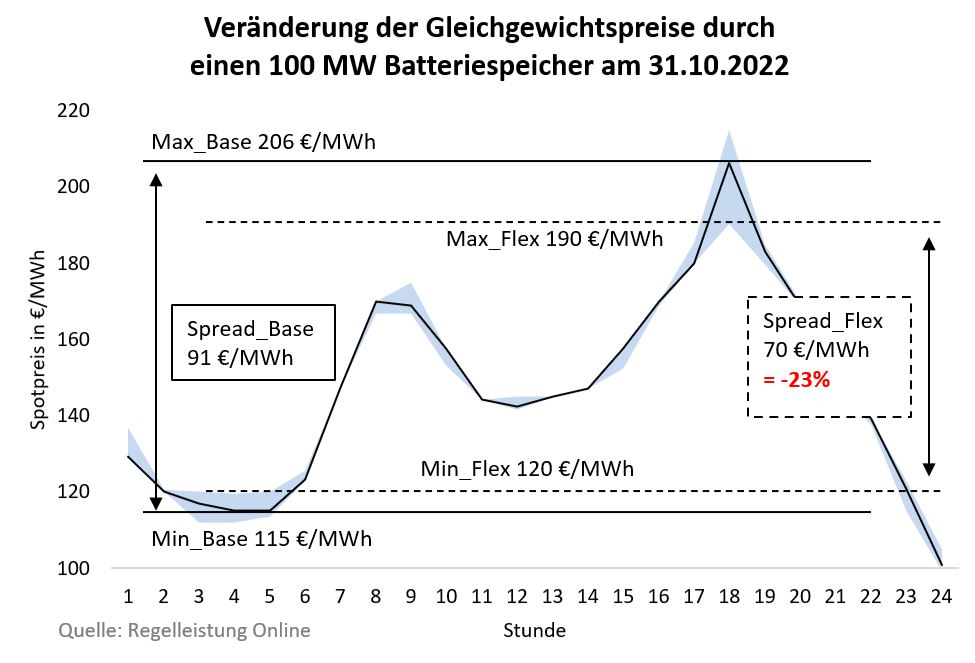
<br> <br>

The buying price (charge) goes UP by €5 — from €115 to €120. The selling price (discharge) goes DOWN by €16 — from €206 to €190. All these in a system that trades at roughly 20,000 MWh every hour. <br> <br>

**When BESS accounts for 0.5% (100 MW) of the German market, it caused a 4.3% increase in the buying price (charge) and 7.8% reduction in the selling price (discharge).** <br> <br>

We know that Ireland's day-ahead market is much smaller than Germany. So, we can use the ratio between the two market shares to scale the price impact. <br> <br>

`Ireland's market share / Germany's market share = how many times bigger Ireland's impact is` <br> <br>

So we need to find out how much 100 MW of BESS represent in Ireland's day-ahead market. <br> <br>

**Steps to Carry Out:** <br> <br>

**1. Calculate Ireland's market share of 100 MW** <br>
Ireland's mandatory pool design (I-SEM) justifies using total system demand as Ireland's denominator, because there is no separate exchange volume in the EPEX sense. Every MWh dispatched in Ireland is priced through the same SMP mechanism, making total system demand the structural equivalent of Schäfer's EPEX auction volume. 

**2. Compare Ireland's market share of 100 MW to Germany's** <br>
**Germany:** 100 MW / 20,000 MW = 0.005 market share → caused 7.8% (EUR 16) decrease in selling price (discharge) <br>
**Ireland:** 100 MW / 430 MWh = 0.232 market share → caused ??% decrease in selling price (discharge)
<br> <br>
`Concentration ratio = Ireland's market share (0.232) / Germany's market share (0.005)`
<br> <br>

This tells you how many times more concentrated 100 MW is in Ireland versus Germany.
<br> <br>

**3. Compare Ireland's mid merit share to Germany's** <br>
Germany has much higher mid merit generation capacity, which gives BESS more room to compress prices because BESS can displace expensive gas plants easier and move it down to a mid merit plant.

<br> <br>
`Mid merit ratio = Ireland's mid merit share / Germany's mid merit share`
<br> <br>

**4. Get the Adjusted Cannibalisation Rate for 100 MW of BESS for Ireland**

<br> <br>
`Adjusted cannibalisation = 7.8% * Mid merit ratio * Concentration ratio`
<br> <br>

**5. Scale for 500 MW** <br>
Multiply each result by 5 since I have 500 MW not 100 MW.
<br> <br>

**6. Calculate Min Selling Price** 
<br> <br>
`Min Selling Price = Max Selling Price (162.98) - scaled €/MWh reduction`
<br> <br>



https://www.semopx.com/sites/semopx/files/2026-02/SEMOpx%20Monthly%20mrkt%20report%20January%202026_0.pdf

In [9]:
system_df = pd.read_excel("/Users/Casual/Documents/TISE/04_UWK/01_Thesis/04_Data/System Data/Merged_System_data.xlsx")

system_df.head(10)

,DateTime,GMT Offset,NI Generation,NI Demand,NI Wind Availability,NI Wind Generation,NI Solar Availability,NI Solar Generation,Moyle I/C,NI Wind Penetration,...,Inter-Jurisdictional Flow,AI Wind Penetration,AI Solar Penetration,AI Oversupply,AI Oversupply Percentage,SNSP,Unnamed: 34,Unnamed: 35,NI: Northern Ireland \nIE: Ireland \nAI: All Island,Unnamed: 37
0,2023-01-01 00:00:00,0,549.428,698.592,74.460,68.182,0.0,0.0,441.707,0.097599,...,-281.44,0.172659,0.0,0.0,0.0,0.3980,NaN,NaN,NaN,NaN
1,2023-01-01 00:15:00,0,539.795,690.979,59.066,53.057,0.0,0.0,441.708,0.076785,...,-278.69,0.180339,0.0,0.0,0.0,0.4068,NaN,NaN,NaN,NaN
2,2023-01-01 00:30:00,0,515.361,680.457,45.255,39.071,0.0,0.0,441.692,0.057419,...,-264.22,0.175528,0.0,0.0,0.0,0.4040,NaN,NaN,NaN,NaN
3,2023-01-01 00:45:00,0,515.984,671.077,36.929,30.872,0.0,0.0,441.703,0.046004,...,-275.05,0.179346,0.0,0.0,0.0,0.4032,NaN,NaN,NaN,NaN
4,2023-01-01 01:00:00,0,513.071,684.374,30.711,24.044,0.0,0.0,441.724,0.035133,...,-258.29,0.180756,0.0,0.0,0.0,0.3984,NaN,NaN,NaN,NaN
5,2023-01-01 01:15:00,0,486.135,683.119,22.523,15.666,0.0,0.0,441.718,0.022933,...,-229.66,0.188061,0.0,0.0,0.0,0.4072,NaN,NaN,NaN,NaN
6,2023-01-01 01:30:00,0,488.127,672.753,17.154,10.535,0.0,0.0,411.234,0.015660,...,-212.38,0.197976,0.0,0.0,0.0,0.4116,NaN,NaN,NaN,NaN
7,2023-01-01 01:45:00,0,487.921,659.473,14.343,8.400,0.0,0.0,392.422,0.012737,...,-205.17,0.192843,0.0,0.0,0.0,0.4055,NaN,NaN,NaN,NaN
8,2023-01-01 02:00:00,0,497.061,653.497,9.859,4.740,0.0,0.0,392.411,0.007253,...,-223.77,0.185456,0.0,0.0,0.0,0.4005,NaN,NaN,NaN,NaN
9,2023-01-01 02:15:00,0,499.252,642.700,9.338,4.045,0.0,0.0,392.417,0.006294,...,-238.61,0.169793,0.0,0.0,0.0,0.3888,NaN,NaN,NaN,NaN


In [10]:
price_df.dtypes

Country                     object
ISO3 Code                   object
Datetime (UTC)              object
Datetime (Local)    datetime64[ns]
Price (EUR/MWhe)           float64
Year                         int32
Date                        object
Hour                         int32
dtype: object

In [11]:
# Convert DateTime to correct format 
system_df["DateTime"] = pd.to_datetime(system_df["DateTime"]) # Watch out its DateTime not Datetime. Capital T.

system_df["Year"] = system_df["DateTime"].dt.year
system_df["Date"] = system_df["DateTime"].dt.date
system_df["Hour"] = system_df["DateTime"].dt.hour

# Filter the dataset to 2023, 2024, 2025 and IE Demand
system_df_filtered = system_df[system_df["Year"].isin([2023, 2024, 2025])][["DateTime", "IE Demand"]]

system_df_filtered

,DateTime,IE Demand
0,2023-01-01 00:00:00,3325.66
1,2023-01-01 00:15:00,3302.37
2,2023-01-01 00:30:00,3260.80
3,2023-01-01 00:45:00,3219.12
4,2023-01-01 01:00:00,3197.17
...,...,...
105211,2025-12-31 22:45:00,3964.17
105212,2025-12-31 23:00:00,4042.01
105213,2025-12-31 23:15:00,4036.00
105214,2025-12-31 23:30:00,3986.13


In [12]:
# Convert dataset to hourly
hour_system_df_filtered = (system_df_filtered
                           .set_index("DateTime")
                           .resample("h")["IE Demand"]
                           .mean()
                           #.reset_index()
                          )

# Previously: 105,215 rows. After grouping: 26,304 rows. 105,215/ 4 = 26,303.75

hour_system_df_filtered

DateTime
2023-01-01 00:00:00    3276.9875
2023-01-01 01:00:00    3132.7550
2023-01-01 02:00:00    2987.2775
2023-01-01 03:00:00    2890.7075
2023-01-01 04:00:00    2824.6475
                         ...    
2025-12-31 19:00:00    4730.4850
2025-12-31 20:00:00    4444.6750
2025-12-31 21:00:00    4221.8275
2025-12-31 22:00:00    4014.2725
2025-12-31 23:00:00    3998.1825
Freq: h, Name: IE Demand, Length: 26304, dtype: float64

In [13]:
### Step 1: Calculate Ireland's market share

# Average hourly demand across 2023 - 2025
avg_hourly_demand_2023_2025 = hour_system_df_filtered.mean()
print(f"Avg Hourly Demand (2023 - 2025): {avg_hourly_demand_2023_2025:.2f} MW")

# Please note that the unit is MW

# Calculate the size of 100 MW in Irish market share.
# Ireland's market share = 100 / average hourly Irish demand × 100

irish_market_share_100_MW = 100/ avg_hourly_demand_2023_2025

print(f"Ireland's market share (100 MW): {irish_market_share_100_MW:.4f}")

# So we know that in Ireland, 100 MW accounts for 2.61% of market share.
# In Germany, 100 MW accounts for just 0.19% of market share.

Avg Hourly Demand (2023 - 2025): 3833.29 MW
Ireland's market share (100 MW): 0.0261


In [14]:
### Step 2: Compare Ireland's market share to Germany's
# Concentration ratio = Ireland's market share / Germany's market share (0.5%)

concentration_ratio = irish_market_share_100_MW / 0.001880 # 0.5% = 0.005
print(f"Concentration Ratio = {concentration_ratio:.4f}")

# It means that 100 MW in Ireland is 13.8762 times more concentrated in the market than 100 MW in Germany.
# The same action in Germany could have an impact that is roughly 13.8762 times larger in Ireland.

Concentration Ratio = 13.8762



**Ireland (As of 2026)** 

<br> <br>
https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fcms.eirgrid.ie%2Fsites%2Fdefault%2Ffiles%2Fpublications%2FAIRAA-2026-2035_DataWorkbook.xlsx&wdOrigin=BROWSELINK
<br> <br>

Mid merit: Biomass and Biogas, Industrial, Conventional CHP, Biomass CHP, Milled peat/ Biomass
<br> <br>

| Category | Installed Capacity | % |
| --- | --- | --- |
| Zero cost | 9350 | 59.71 |
| Mid merit | 311 | 1.98 |
| Below gas | 9661 | 61.70 |
| Gas & above | 4854 | 31.00 |
| Total | 15657 | 100 |

---

**Ireland's Installed Capacity (Ordered by Merit Order)** <br> <br>
| Fuel Type | Installed Capacity (MW) |
| --- | --- |
| Wind Onshore |	5740 |
| Wind Offshore	| 30 |
| Solar PV	| 3260 |
| Small Scale Hydro	| 26 |
| Hydro	| 216 |
| Waste	| 78 |
| Industrial |	9 |
| Biomass and Biogas |	24 |
| Conventional CHP |	130 |
| Biomass CHP |	30 |
| Milled peat/ Biomass |	118 |
| Gas/Multi Fuel |	192 |
| Gas/DO	| 3578 |
| DO/Gas |	116 |
| DO	| 208 |
| DSU |	760 |

In [15]:
### Step 3: Compare Ireland's mid merit share to Germany's

# Ireland Below Gas Stack 
ireland_mid_merit_stack = 311
ireland_total_capacity = 15657
ireland_mid_merit_share = ireland_mid_merit_stack/ ireland_total_capacity * 100

print(f"Ireland's Share of Mid Merit Stack = {ireland_mid_merit_share:.2f}%")

Ireland's Share of Mid Merit Stack = 1.99%


**Germany (As of Nov 2025)** 

<br> <br>
https://www.bundesnetzagentur.de/EN/Areas/Energy/SecurityOfSupply/GeneratingCapacity/PowerPlantList/start.html
<br> <br>

Mid merit: Biomass, Hard Coal, Lignite
<br> <br>

| Category | Installed Capacity | % |
| --- | --- | --- |
| Zero cost | 179733 | 68.96 |
| Mid merit | 32519 | 12.47 |
| Below gas | 209800 | 80.49 |
| Gas & above | 40938 | 15.70 |
| Total | 260632 | 100 |

---

**Germany Installed Capacity (Ordered by Merit Order)** <br>
| Fuel Type | Installed Capacity (MW) |
| --- | --- |
| Solar |	95802 |
| Wind (offshore) | 9215 |
| Wind (onshore) |	65405 |
| Hydro	| 5889 |
| Other enrgy sources (renewable) | 970 |
| Biomass |	9055 |
| Lignite |	14758 |
| Hard coal	| 8706 |
| Natural gas |	30179 |
| Petroleum |	2452 |
| Other energy sources (non-renewable) |	8307 |
| Pumped storage |	9894 |

In [16]:
# Germany Below Gas Stack
germany_mid_merit_stack = 32519
germany_total_capacity = 260632
germany_mid_merit_share = germany_mid_merit_stack/ germany_total_capacity * 100

print(f"Germany's Share of Mid Merit Stack = {germany_mid_merit_share:.2f}%")

mid_merit_ratio = ireland_mid_merit_share/ germany_mid_merit_share

print(f"Mid Merit Ratio = {mid_merit_ratio:.4f}")

Germany's Share of Mid Merit Stack = 12.48%
Mid Merit Ratio = 0.1592


In [17]:
### Step 4: Get the Adjusted Cannibalisation Rate for 100 MW of BESS for Ireland
# Adjusted cannibalisation = 7.8% * Mid merit ratio * Concentration ratio

adjusted_selling_cannibalisation_100MW = 7.8 * mid_merit_ratio * concentration_ratio

print(f"Adjusted Selling Cannibalisation for 100 MW = {adjusted_selling_cannibalisation_100MW:.4f}%")

### Step 5: Scale for 500 MW

adjusted_selling_cannibalisation_500MW = adjusted_selling_cannibalisation_100MW * 5

print(f"Adjusted Selling Cannibalisation for 500 MW = {adjusted_selling_cannibalisation_500MW:.4f}%")

### Step 6: Calculate MIN SELLING PRICE
# Min Selling Price = Max Selling Price (162.98) - scaled €/MWh reduction

min_selling_price = max_selling_price - (max_selling_price * adjusted_selling_cannibalisation_500MW/ 100)

print(f"MIN SELLING PRICE = {min_selling_price:.2f}")

Adjusted Selling Cannibalisation for 100 MW = 17.2309%
Adjusted Selling Cannibalisation for 500 MW = 86.1543%
MIN SELLING PRICE = 22.57


# ----------- AVERAGE BUYING PRICE SECTION ------------
## Min Buying Price
### Average of Cheapest 4 Hours Everyday

In [18]:
# Sort data by Date and then Price (lowest to highest)
price_df_filtered_sorted = price_df_filtered.sort_values(by = ["Date", "Price (EUR/MWhe)"])
price_df_filtered_sorted.head()

# For every day, take the cheapest 4 hours 
cheapest_4_hours_buy = price_df_filtered_sorted.groupby("Date").head(4)

cheapest_4_hours_buy.head(10)

,Country,ISO3 Code,Datetime (UTC),Datetime (Local),Price (EUR/MWhe),Year,Date,Hour
37256,Ireland,IRL,2023-01-01 06:00:00,2023-01-01 06:00:00,149.10,2023,2023-01-01,6
37257,Ireland,IRL,2023-01-01 07:00:00,2023-01-01 07:00:00,151.52,2023,2023-01-01,7
37254,Ireland,IRL,2023-01-01 04:00:00,2023-01-01 04:00:00,158.00,2023,2023-01-01,4
37253,Ireland,IRL,2023-01-01 03:00:00,2023-01-01 03:00:00,158.36,2023,2023-01-01,3
37280,Ireland,IRL,2023-01-02 06:00:00,2023-01-02 06:00:00,136.30,2023,2023-01-02,6
37279,Ireland,IRL,2023-01-02 05:00:00,2023-01-02 05:00:00,142.53,2023,2023-01-02,5
37277,Ireland,IRL,2023-01-02 03:00:00,2023-01-02 03:00:00,144.71,2023,2023-01-02,3
37278,Ireland,IRL,2023-01-02 04:00:00,2023-01-02 04:00:00,144.71,2023,2023-01-02,4
37320,Ireland,IRL,2023-01-03 22:00:00,2023-01-03 22:00:00,97.52,2023,2023-01-03,22
37321,Ireland,IRL,2023-01-03 23:00:00,2023-01-03 23:00:00,127.98,2023,2023-01-03,23


In [19]:
# Average cheapest across 2023 - 2025 (Min Buying Price)
min_buying_price = cheapest_4_hours_buy["Price (EUR/MWhe)"].mean()
print("--- Average Prices 2023 - 2025 ---")
print(f"Overall (2023 - 2025): {min_buying_price}")

yearly_avg_cheapest_buy = cheapest_4_hours_buy.groupby("Year")["Price (EUR/MWhe)"].mean()
print("\n--- Average Prices per Year ---")
print(yearly_avg_cheapest_buy)

--- Average Prices 2023 - 2025 ---
Overall (2023 - 2025): 81.05023950729927

--- Average Prices per Year ---
Year
2023    94.314836
2024    72.863893
2025    75.994418
Name: Price (EUR/MWhe), dtype: float64


## Max Buying Price¶
### Approach 1 (Max Buying Price): Average of Most Expensive 4 Hours from Off Peak Times (11 pm - 6 am)

In [20]:
# Try to see the average price every hour
hourly_avg = price_df_filtered.groupby("Hour")["Price (EUR/MWhe)"].mean()

hourly_avg

Hour
0      97.441359
1      93.020246
2      90.344471
3      88.054498
4      87.743622
5      90.968777
6     105.178923
7     123.815082
8     135.576451
9     134.988449
10    126.351606
11    117.844562
12    114.488659
13    109.446807
14    107.226487
15    111.181259
16    126.636305
17    148.034626
18    155.315958
19    148.930420
20    139.163239
21    128.620438
22    110.809690
23    105.545584
Name: Price (EUR/MWhe), dtype: float64

https://www.bordgaisenergy.ie/home/off-peak-savings

Bord Gais defined off peak hours (night rates) from 11 pm - 8 am. Based on historical data, the average cheapest prices are from 11 pm - 6 pm. The price jumped at 7pm. Hence, for the purpose of this model, the Max Buying Price will be the average of the 4 most expensive hours from **11pm - 6 pm**.

In [21]:
# Filter data for offpeak hours only
offpeak_hours = [23, 0, 1, 2, 3, 4, 5, 6]

df_offpeak = price_df_filtered[price_df_filtered["Hour"].isin(offpeak_hours)]

df_offpeak.head(10)

,Country,ISO3 Code,Datetime (UTC),Datetime (Local),Price (EUR/MWhe),Year,Date,Hour
37250,Ireland,IRL,2023-01-01 00:00:00,2023-01-01 00:00:00,186.28,2023,2023-01-01,0
37251,Ireland,IRL,2023-01-01 01:00:00,2023-01-01 01:00:00,183.99,2023,2023-01-01,1
37252,Ireland,IRL,2023-01-01 02:00:00,2023-01-01 02:00:00,165.00,2023,2023-01-01,2
37253,Ireland,IRL,2023-01-01 03:00:00,2023-01-01 03:00:00,158.36,2023,2023-01-01,3
37254,Ireland,IRL,2023-01-01 04:00:00,2023-01-01 04:00:00,158.00,2023,2023-01-01,4
37255,Ireland,IRL,2023-01-01 05:00:00,2023-01-01 05:00:00,160.68,2023,2023-01-01,5
37256,Ireland,IRL,2023-01-01 06:00:00,2023-01-01 06:00:00,149.10,2023,2023-01-01,6
37273,Ireland,IRL,2023-01-01 23:00:00,2023-01-01 23:00:00,166.10,2023,2023-01-01,23
37274,Ireland,IRL,2023-01-02 00:00:00,2023-01-02 00:00:00,160.38,2023,2023-01-02,0
37275,Ireland,IRL,2023-01-02 01:00:00,2023-01-02 01:00:00,157.75,2023,2023-01-02,1


In [22]:
# Sort data by Date then Price (highest to lowest)
df_offpeak_sorted = df_offpeak.sort_values(by = ["Date", "Price (EUR/MWhe)"], ascending = [True, False])

df_offpeak_sorted.head(20)

# For every day from offpeak, take the most expensive 4 hours 
expensive_4_hours_buy = df_offpeak_sorted.groupby("Date").head(4)

expensive_4_hours_buy.head(10)

,Country,ISO3 Code,Datetime (UTC),Datetime (Local),Price (EUR/MWhe),Year,Date,Hour
37250,Ireland,IRL,2023-01-01 00:00:00,2023-01-01 00:00:00,186.28,2023,2023-01-01,0
37251,Ireland,IRL,2023-01-01 01:00:00,2023-01-01 01:00:00,183.99,2023,2023-01-01,1
37273,Ireland,IRL,2023-01-01 23:00:00,2023-01-01 23:00:00,166.10,2023,2023-01-01,23
37252,Ireland,IRL,2023-01-01 02:00:00,2023-01-01 02:00:00,165.00,2023,2023-01-01,2
37297,Ireland,IRL,2023-01-02 23:00:00,2023-01-02 23:00:00,180.00,2023,2023-01-02,23
37274,Ireland,IRL,2023-01-02 00:00:00,2023-01-02 00:00:00,160.38,2023,2023-01-02,0
37275,Ireland,IRL,2023-01-02 01:00:00,2023-01-02 01:00:00,157.75,2023,2023-01-02,1
37276,Ireland,IRL,2023-01-02 02:00:00,2023-01-02 02:00:00,147.50,2023,2023-01-02,2
37299,Ireland,IRL,2023-01-03 01:00:00,2023-01-03 01:00:00,200.24,2023,2023-01-03,1
37298,Ireland,IRL,2023-01-03 00:00:00,2023-01-03 00:00:00,200.00,2023,2023-01-03,0


In [23]:
# Average of 4 Most Expensive Hours (Off-Peak) across 2023 - 2025 (Max Buying Price)
max_buying_price_1 = expensive_4_hours_buy["Price (EUR/MWhe)"].mean()
print("--- Average Prices 2023 - 2025 ---")
print(f"Overall (2023 - 2025): {max_buying_price_1:.2f}")
print(f"MAX BUYING PRICE = {max_buying_price_1:.2f}")

# Average yearly 4 most expensive hours (off-peak)
yearly_avg_expensive_buy = expensive_4_hours_buy.groupby("Year")["Price (EUR/MWhe)"].mean()
print("--- Average Prices per Year ---")
print(yearly_avg_expensive_buy)

--- Average Prices 2023 - 2025 ---
Overall (2023 - 2025): 103.76
MAX BUYING PRICE = 103.76
--- Average Prices per Year ---
Year
2023    114.300644
2024     94.395212
2025    102.616795
Name: Price (EUR/MWhe), dtype: float64


### Approach 2 (Max Buying Price): Schafer Study Scaling 

https://www.pv-magazine.de/2023/07/11/preiseffekte-durch-den-ausbau-von-batteriespeichern-teil-3-arbitrage-in-der-day-ahead-auktion/
<br> <br>

This follows the same steps laid out in MIN SELLING PRICE above.  

Price increase from EUR 115 to EUR 120. That's 4.3% increase.  

Since everything is calculated already, we just need to do Step 4 - Step 6.  

In [24]:
### Step 4: Get the Adjusted Cannibalisation Rate for 100 MW of BESS for Ireland
# Adjusted cannibalisation = 4.8% * Mid merit ratio * Concentration ratio

adjusted_buying_cannibalisation_100MW = 4.8 * mid_merit_ratio * concentration_ratio

print(f"Adjusted Buying Cannibalisation for 100 MW = {adjusted_buying_cannibalisation_100MW:.4f}%")

### Step 5: Scale for 500 MW

adjusted_buying_cannibalisation_500MW = adjusted_buying_cannibalisation_100MW * 5

print(f"Adjusted Buying Cannibalisation for 500 MW = {adjusted_buying_cannibalisation_500MW:.4f}%")

### Step 6: Calculate MAX BUYING PRICE
# Max Buying Price = Min Buying Price (81.05) + scaled €/MWh reduction

max_buying_price_2 = min_buying_price + (min_buying_price * adjusted_buying_cannibalisation_500MW/ 100)

print(f"MAX BUYING PRICE = {max_buying_price_2:.2f}")

Adjusted Buying Cannibalisation for 100 MW = 10.6036%
Adjusted Buying Cannibalisation for 500 MW = 53.0180%
MAX BUYING PRICE = 124.02
